# Fall Detection: IMU Classifier Training (v2.0)
This notebook trains a neural network to distinguish between **FALL** and **NORMAL** (Negative) events using 1 second of IMU data (Accel/Gyro).

### 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Parameters from IMU_Fall_Capture.ino
SAMPLES_PER_GESTURE = 120
NUM_CHANNELS = 6 # ax, ay, az, gx, gy, gz
CLASSES = ['fall', 'normal']

c:\Jon\Uni stuff\CE\Embedded-Systems\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### 2. Load and Preprocess Data
This section reads your CSV files and splits them into individual 1-second "gestures."

In [2]:
# -------------------------------
# 1. Load + Parse action Data
# -------------------------------
def load_action_data(filename, class_id):
    actions = []
    current_action = []

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()

            if line == "--- TRIGGERED ---":
                current_action = []
                continue

            if "Capture Finished" in line:
                if len(current_action) > 0:
                    actions.append(current_action)
                current_action = []
                continue

            parts = line.split(',')
            if len(parts) == NUM_CHANNELS:
                try:
                    values = [float(x) for x in parts]
                    current_action.append(values)
                except ValueError:
                    continue

    print(f"{filename}: Found {len(actions)} actions.")

    # -------------------------------
    # 2. Pad / Trim actions
    # -------------------------------
    processed_actions = []

    for a in actions:
        g = np.array(a)   # FIXED (was bug: used g instead of a)

        if len(g) < SAMPLES_PER_GESTURE:
            padding = np.zeros((SAMPLES_PER_GESTURE - len(g), NUM_CHANNELS))
            g = np.vstack((g, padding))
        else:
            g = g[:SAMPLES_PER_GESTURE]

        # KEEP 3D shape (DO NOT flatten yet)
        processed_actions.append(g)

    X = np.array(processed_actions)  # shape: (samples, time, 6)
    y = np.full((len(X),), class_id)

    print(f"{filename}: Usable actions: {len(X)}")
    return X, y


# -------------------------------
# 3. Load datasets
# -------------------------------
try:
    fall_data, fall_labels = load_action_data('fall_data.csv', 0)
    normal_data, normal_labels = load_action_data('normal_data.csv', 1)

    # Combine
    X = np.concatenate((fall_data, normal_data), axis=0)
    y = np.concatenate((fall_labels, normal_labels))

    print("\nBefore split:")
    print(f"Total Samples: {len(X)}")

    # -------------------------------
    # 4. Train / Val / Test split
    # -------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
    )

    print("\nAfter split:")
    print(f"Training: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    # -------------------------------
    # 5. PHYSICS-BASED NORMALIZATION (OPTION B)
    # -------------------------------

    # Split accel vs gyro
    accel_train = X_train[:, :, 0:3]
    gyro_train  = X_train[:, :, 3:6]

    accel_val = X_val[:, :, 0:3]
    gyro_val  = X_val[:, :, 3:6]

    accel_test = X_test[:, :, 0:3]
    gyro_test  = X_test[:, :, 3:6]

    # Normalize using sensor physical ranges
    # accel assumed ±2g (safer default)
    accel_train = (accel_train + 3.0) / 6.0
    accel_val   = (accel_val + 3.0) / 6.0
    accel_test  = (accel_test + 3.0) / 6.0

    # gyro assumed ±250 dps (very common safe mode)
    gyro_train = (gyro_train + 400.0) / 800.0
    gyro_val   = (gyro_val + 400.0) / 800.0
    gyro_test  = (gyro_test + 400.0) / 800.0

    # Recombine
    X_train = np.concatenate([accel_train, gyro_train], axis=2)
    X_val   = np.concatenate([accel_val, gyro_val], axis=2)
    X_test  = np.concatenate([accel_test, gyro_test], axis=2)

    # #shuffle
    # X_train, y_train = shuffle(X_train, y_train, random_state=44)

    print("\nPhysics-based normalization applied (accel + gyro separately scaled).")

except FileNotFoundError:
    print("Error: CSV files not found. Please run your data collector first!")

fall_data.csv: Found 150 actions.
fall_data.csv: Usable actions: 150
normal_data.csv: Found 150 actions.
normal_data.csv: Usable actions: 150

Before split:
Total Samples: 300

After split:
Training: 180
Validation: 60
Test: 60

Physics-based normalization applied (accel + gyro separately scaled).


In [3]:
print("Shape:", X_train.shape)
print("First sample:\n", X_train[0])

Shape: (180, 120, 6)
First sample:
 [[ 0.50933333  0.567       0.646       0.50267     0.500305    0.49946625]
 [ 0.51133333  0.566       0.64533333  0.505875    0.502365    0.49931375]
 [ 0.51116667  0.56583333  0.64466667  0.50701875  0.5033575   0.49961875]
 [ 0.5105      0.56566667  0.64383333  0.50831625  0.50473     0.4995425 ]
 [ 0.50883333  0.5655      0.64266667  0.51052875  0.50564625  0.498855  ]
 [ 0.509       0.56516667  0.64283333  0.5145725   0.50679     0.49855   ]
 [ 0.511       0.56416667  0.64333333  0.5157925   0.50732375  0.4983975 ]
 [ 0.51233333  0.56316667  0.64366667  0.5172425   0.507935    0.498245  ]
 [ 0.51333333  0.56333333  0.64333333  0.52189625  0.51098625  0.49786375]
 [ 0.51383333  0.56266667  0.6415      0.5249475   0.5145725   0.49755875]
 [ 0.515       0.55983333  0.63916667  0.5290675   0.51876875  0.49740625]
 [ 0.51466667  0.5565      0.63483333  0.53440875  0.522125    0.497025  ]
 [ 0.51216667  0.56166667  0.63033333  0.5287625   0.520065    0

### 3. Model Architecture
We use a Dense (MLP) network for motion classification, which is lightweight for the Nano 33.

In [23]:
# -------------------------------
# 1. Reset model
# -------------------------------
tf.keras.backend.clear_session()

# -------------------------------
# 2. Reshape input for CNN
# -------------------------------
# Ensure your X is:
# (samples, timesteps, features)
X_train_cnn = X_train.reshape(-1, SAMPLES_PER_GESTURE, NUM_CHANNELS, 1)  # Add channel dimension for CNN
X_val_cnn   = X_val.reshape(-1, SAMPLES_PER_GESTURE, NUM_CHANNELS, 1)
X_test_cnn  = X_test.reshape(-1, SAMPLES_PER_GESTURE, NUM_CHANNELS, 1)

# -------------------------------
# 3. Build CNN model
# -------------------------------
model = models.Sequential([
    layers.Input(shape=(SAMPLES_PER_GESTURE, NUM_CHANNELS, 1)),

    # Layer 1: Kernel (3, 6) spans all sensors to find cross-axis correlations
    layers.SeparableConv2D(16, kernel_size=(3, 6), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 1)),

    # Layer 2: Now that width is 1, we only filter across the time axis (3, 1)
    layers.SeparableConv2D(32, kernel_size=(3, 1), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 1)),
    layers.SeparableConv2D(64, kernel_size=(3, 1), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 1)),

    layers.GlobalAveragePooling2D(),
    # layers.Flatten(),
    
    layers.Dense(32, activation='relu'),
    layers.Dense(len(CLASSES), activation='softmax')
])
# -------------------------------
# 4. Compile
# -------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 5. Early stopping
# -------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# -------------------------------
# 6. Train
# -------------------------------
history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=200,
    batch_size=10,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------
# 7. Evaluate
# -------------------------------
actual_epochs = len(history.history['loss'])
print("Epochs actually run:", actual_epochs)
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("\nTest Accuracy:", test_acc)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4722 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6920 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6891 - val_accuracy: 0.5000 - val_loss: 0.6866
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5167 - loss: 0.6787 - val_accuracy: 0.5833 - 

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 118, 1, 16)     │            50 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 57, 1, 32)      │           592 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 26, 1, 64)      │         2,208 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,990 (58.56 KB)

 Trainable params: 4,996 (19.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,994 (39.04 KB)

### 4. Evaluating the Model
This section tracks the training progress and helps you detect if the model is overfitting.

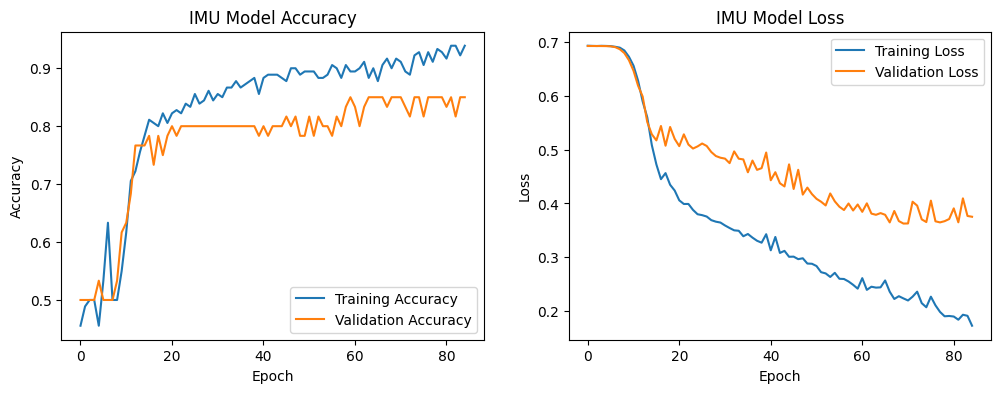

In [20]:
# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('IMU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('IMU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### 5. Confusion Matrix
This heatmap shows how many 'Normal' movements were incorrectly flagged as 'Falls'.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


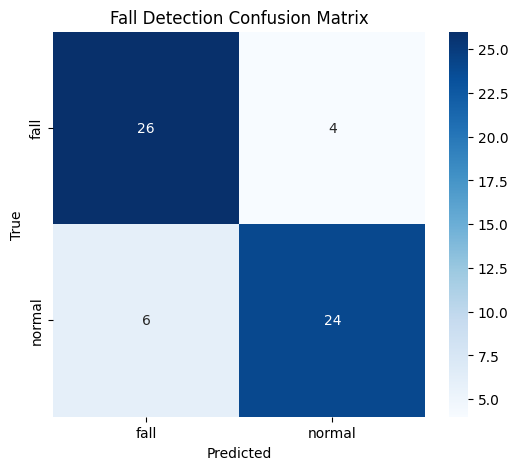

In [24]:
y_pred = np.argmax(model.predict(X_test_cnn), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES,
            yticklabels=CLASSES,
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Fall Detection Confusion Matrix')
plt.show()

## Calculating metrics

In [ ]:
# 1. Get raw counts from the Confusion Matrix
# Based on your CLASSES = ['fall', 'normal'] where Fall=0, Normal=1:
tp = cm[0, 0]  # True Positive: Actually a Fall, predicted as a Fall
fn = cm[0, 1]  # False Negative: Actually a Fall, predicted as Normal (Dangerous!)
fp = cm[1, 0]  # False Positive: Actually Normal, predicted as a Fall (False Alarm)
tn = cm[1, 1]  # True Negative: Actually Normal, predicted as Normal

# 2. Calculate Standard Metrics
# Note: pos_label=0 is used because 'fall' is index 0 in your list
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=0)
recall    = recall_score(y_test, y_pred, pos_label=0)
f1        = f1_score(y_test, y_pred, pos_label=0)

# 3. Calculate False Positive Rate (FPR) 
# FPR tells you how often the system triggers a false alarm during normal activity
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# 4. Print Results
print("--- Detailed Performance Metrics ---")
print(f"True Positives (Falls correctly detected): {tp}")
print(f"False Negatives (Falls missed):           {fn}")
print(f"False Positives (False Alarms):          {fp}")
print(f"True Negatives (Normal activity clear):   {tn}")
print("-" * 35)
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%} (When it triggers, how often is it a real fall?)")
print(f"Recall:    {recall:.2%} (How many total falls did it catch?)")
print(f"F1-Score:  {f1:.4f}")
print(f"False Positive Rate: {fpr:.2%} (Annoyance rate)")

# 5. Full Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

--- Detailed Performance Metrics ---
True Positives (Falls correctly detected): 26
False Negatives (Falls missed):           4
False Positives (False Alarms):          6
True Negatives (Normal activity clear):   24
-----------------------------------
Accuracy:  83.33%
Precision: 81.25% (When it triggers, how often is it a real fall?)
Recall:    86.67% (How many total falls did it catch?)
F1-Score:  0.8387
False Positive Rate: 20.00% (Annoyance rate)

Classification Report:
              precision    recall  f1-score   support

        fall       0.81      0.87      0.84        30
      normal       0.86      0.80      0.83        30

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



### 6. Export to TensorFlow Lite
Finally, convert the model to a C-header file for deployment on the Arduino Nano 33 BLE Sense.

In [135]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]
tflite_model = converter.convert()

# Save the model to disk
with open("fall_model.tflite", "wb") as f:
    f.write(tflite_model)

import os
basic_model_size = os.path.getsize("fall_model.tflite")
print("Model is %d bytes" % basic_model_size)

print("Model converted to TFLite format!")

INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmpydj1e468\assets


INFO:tensorflow:Assets written to: C:\Users\JONATH~1\AppData\Local\Temp\tmpydj1e468\assets


Model is 25708 bytes
Model converted to TFLite format!


In [114]:
fallModel = open("fall_model.tflite", "rb").read()
interpreter = tf.lite.Interpreter(model_content=fallModel)
interpreter.allocate_tensors()

print(interpreter.get_input_details())


[{'name': 'input_1', 'index': 0, 'shape': array([  1, 120,   6]), 'shape_signature': array([ -1, 120,   6]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
